In [125]:
import numpy as np
import pandas as pd
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima 

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import month_plot

In [126]:
df = pd.read_excel(
    "/home/henrique/ic-rodrigo/Controle_Faturamento_2023.xlsx",
    sheet_name="Consumo Médio - Clientes",
)

df.drop(df.iloc[:, 48:68], inplace=True, axis=1)
df.drop("Nº Cliente", inplace=True, axis=1)
df.drop("Cliente", inplace=True, axis=1)

df = df.head()

df1 = df.transpose()
df = df1.rename(columns=df1.iloc[0])
df.drop("UC", inplace=True, axis=0)
df.dropna(inplace=True)

df.index
dates = np.array(df.index, dtype="datetime64[D]")
idx = pd.DatetimeIndex(dates)
df["idx"] = idx
df.set_index("idx", inplace=True)
df.index.freq = "MS"
df

,3003858507,3001084033,3011373971,3001449459,3011504476
idx,,,,,
2019-06-01,1246.0,7160.0,440.0,960.0,1560.0
2019-07-01,1081.0,6520.0,600.0,920.0,1280.0
2019-08-01,1184.0,6840.0,680.0,1120.0,1360.0
2019-09-01,1549.0,7440.0,760.0,1040.0,1680.0
2019-10-01,2045.0,6920.0,560.0,1120.0,1680.0
2019-11-01,4017.0,6920.0,520.0,1240.0,2920.0
2019-12-01,2386.0,7240.0,320.0,1000.0,1960.0
2020-01-01,4239.0,6560.0,440.0,1120.0,2280.0
2020-02-01,2854.0,7440.0,280.0,1200.0,2480.0


In [127]:
df[3011373971] = df[3011373971].replace(0, np.nan)
df

,3003858507,3001084033,3011373971,3001449459,3011504476
idx,,,,,
2019-06-01,1246.0,7160.0,440.0,960.0,1560.0
2019-07-01,1081.0,6520.0,600.0,920.0,1280.0
2019-08-01,1184.0,6840.0,680.0,1120.0,1360.0
2019-09-01,1549.0,7440.0,760.0,1040.0,1680.0
2019-10-01,2045.0,6920.0,560.0,1120.0,1680.0
2019-11-01,4017.0,6920.0,520.0,1240.0,2920.0
2019-12-01,2386.0,7240.0,320.0,1000.0,1960.0
2020-01-01,4239.0,6560.0,440.0,1120.0,2280.0
2020-02-01,2854.0,7440.0,280.0,1200.0,2480.0


In [128]:
df[3011373971]=df[3011373971].interpolate(method ='linear', limit_direction ='forward')

[Text(0.5, 0, ''), Text(0, 0.5, 'Consumo')]

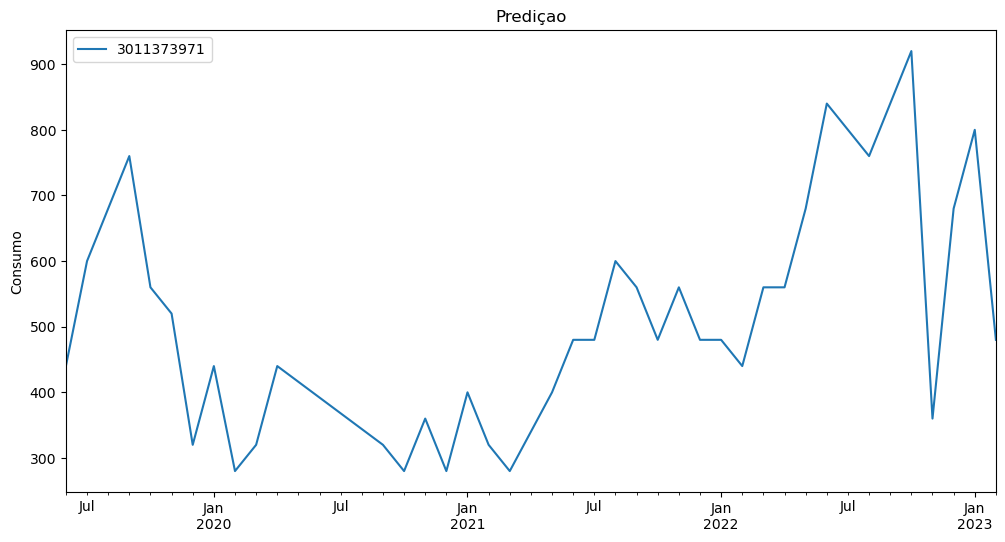

In [129]:
title = "Prediçao"
ylabel = "Consumo"
xlabel = ""

ax = df[3011373971].plot(legend=True, figsize=(12, 6), title=title)
ax.autoscale(axis="x", tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)

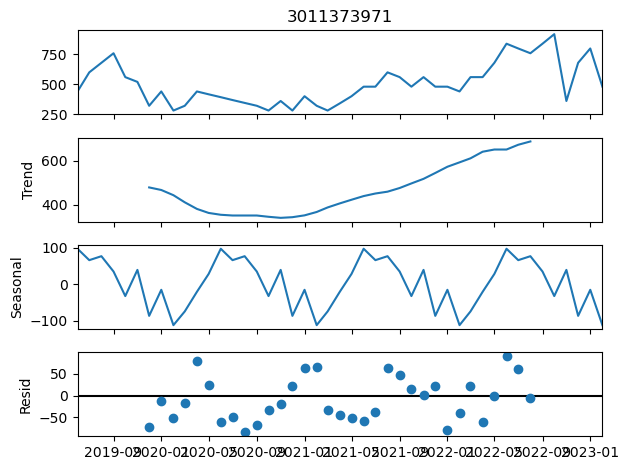

In [130]:
result = seasonal_decompose(df[3011373971], model="add")
result.plot();

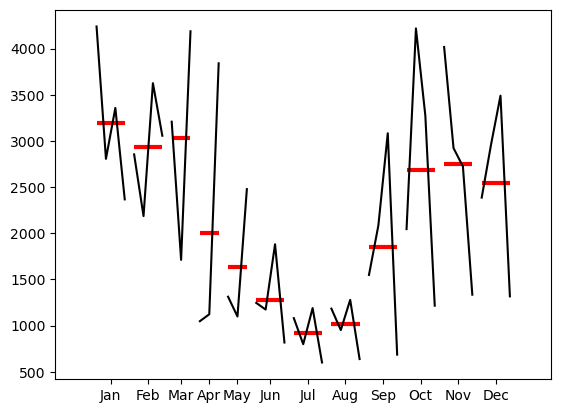

In [131]:
month_plot(df[3003858507]);

In [132]:
auto_arima(
    df[3011373971],
    m=12,
    seasonal=True,
).summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   45
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -276.285
Date:                Mon, 15 Jan 2024   AIC                            556.570
Time:                        11:16:29   BIC                            560.139
Sample:                    06-01-2019   HQIC                           557.894
                         - 02-01-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.4730      0.161     -2.944      0.003      -0.788      -0.158
sigma2      1.653e+04   2576.874      6.415      0.000    1.15e+04    2.16e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                44.67
Prob(Q):                              0.90   Prob(JB):                         0.00
Heteroskedasticity (H):               2.37   Skew:                            -1.51
Prob(H) (two-sided):                  0.11   Kurtosis:                         6.90
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [133]:
train = df.iloc[:40]
test = df.iloc[40:]

test = test.astype(float)
train = train.astype(float)

model = SARIMAX(train[3011373971], order=(1, 1, 1), seasonal_order=(0,0,3,12))
results = model.fit()

 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            6     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  5.77600D+00    |proj g|=  1.56617D-01

At iterate    5    f=  5.73459D+00    |proj g|=  2.93784D-03

At iterate   10    f=  5.73062D+00    |proj g|=  2.68546D-02

At iterate   15    f=  5.72765D+00    |proj g|=  1.10401D-02

At iterate   20    f=  5.72558D+00    |proj g|=  1.43791D-03

At iterate   25    f=  5.72548D+00    |proj g|=  4.15881D-04

At iterate   30    f=  5.72534D+00    |proj g|=  4.42299D-03

At iterate   35    f=  5.72457D+00    |proj g|=  2.82255D-03

At iterate   40    f=  5.72450D+00    |proj g|=  1.30159D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg 

In [134]:
start = len(train)
end = len(train) + len(test) - 1
interpolated_predictions = results.predict(
    start=0, end=end, dynamic=False, typ="levels"
).rename("SARIMA Predictions")

intepolated_future_predictions = results.predict(
    start=end, end=end + 24, dynamic=False, typ="levels"
).rename("SARIMA Future Predictions")

for i in range(len(interpolated_predictions)):
    print(
        f"predição={interpolated_predictions[i]}, esperado={df[3011373971][i]}, erro={np.abs((interpolated_predictions[i]-df[3011373971][i])/(df[3011373971][i]))*100}%"
    )

predição=0.0, esperado=440.0, erro=100.0%
predição=439.5239128555929, esperado=600.0, erro=26.746014524067846%
predição=580.5749530288638, esperado=680.0, erro=14.621330436931798%
predição=688.452481621638, esperado=760.0, erro=9.414147155047639%
predição=744.4386976634556, esperado=560.0, erro=32.93548172561708%
predição=592.2325074117794, esperado=520.0, erro=13.890866809957567%
predição=493.76136971553484, esperado=320.0, erro=54.30042803610464%
predição=359.5418731677514, esperado=440.0, erro=18.28593791642013%
predição=394.7391724626733, esperado=280.0, erro=40.97827587952618%
predição=332.8777156285869, esperado=320.0, erro=4.024286133933401%
predição=267.93228304521665, esperado=440.0, erro=39.10629930790531%
predição=481.9629879481284, esperado=416.0, erro=15.856487487530863%
predição=378.8910450298769, esperado=392.0, erro=3.3441211658477243%
predição=469.44129685638495, esperado=368.0, erro=27.565569797930696%
predição=371.37525318931716, esperado=344.0, erro=7.95792243875499

[Text(0.5, 0, ''), Text(0, 0.5, 'Consumo')]

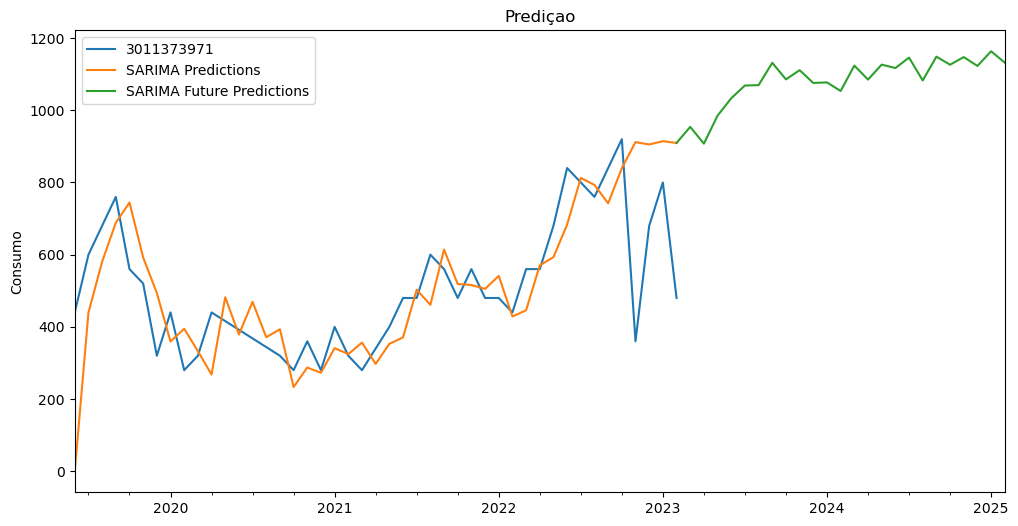

In [135]:
title = "Prediçao"
ylabel = "Consumo"
xlabel = ""

ax = df[3011373971].plot(legend=True, figsize=(12, 6), title=title)
interpolated_predictions.plot(legend=True)
intepolated_future_predictions.plot(legend=True)
ax.autoscale(axis="x", tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)